<a href="https://colab.research.google.com/github/twahanur/Heart-Disease-prediction-improve-IOP-paper-2021/blob/main/HeartDiseasePredectionInML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Packages import and Load the dataset

In [25]:
# ==================== HEART DISEASE PREDICTION - CLEAN VERSION ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

# Dataset Load
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = pd.read_csv(url, names=columns, na_values='?')

print("Dataset Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Dataset Shape: (303, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


### missing value ki vabe handle korechi ar split
Ekhane Missing valuer row gula drop kre daoya hosche
opor e dekchi j "**ca**" 4 ta row te null and "**thal**" 2 ta row te null.
jehetu ekhane olpo value null tai amra se gula drop kore dibo
jodi beshi value null hoto tokhon **min/max/average** akta value bosiye ditam

### Data split
amra **sklearn** theke train test split function bebohar kore 3:1 onupate data k vag korechi
ekhane 297 datar vetor amra train er jnno 222 ta data ar test er jnno 75 ta data rekhechi


In [27]:
# Missing value + Target encoding
df = df.dropna()
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("After preprocessing shape:", df.shape)

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

After preprocessing shape: (297, 14)
Training samples: 222
Testing samples: 75


### model create
amra 3 ta model e test korbo. j model ta vlo kaj korbe seta k amra select korbo


1.   Linear regression
2.   KNN
3.   Random Forest

amra opor e ei algorithm gula import kore esechi
akn sekhane amra firls e model function gula load korechi kicu defult value diye

ekhane amra standardScaller diye value gula k 0-1 er vetor niye aschi
then amra sei scaled value gula diye amra model k train korbo.
tarpor amra accuracy test krechi



In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Original Models
lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr.predict(X_test_scaled))*100:.2f}%")
print(f"KNN Accuracy               : {accuracy_score(y_test, knn.predict(X_test_scaled))*100:.2f}%")
print(f"Random Forest Accuracy     : {accuracy_score(y_test, rf.predict(X_test))*100:.2f}%")

Logistic Regression Accuracy: 90.67%
KNN Accuracy               : 81.33%
Random Forest Accuracy     : 86.67%


In [ ]:
### model average
eta dorkar na. amra model gular accuracy er akta average ber korechi


In [29]:
# Best Models
best_knn = KNeighborsClassifier(metric='manhattan', n_neighbors=13, weights='uniform')
best_lr  = LogisticRegression(C=1, solver='liblinear', max_iter=1000)
best_rf  = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42)

best_knn.fit(X_train_scaled, y_train)
best_lr.fit(X_train_scaled, y_train)
best_rf.fit(X_train, y_train)

# Weighted Voting
weighted_voting = VotingClassifier(
    estimators=[('lr', best_lr), ('knn', best_knn), ('rf', best_rf)],
    voting='soft',
    weights=[3, 1, 2]
)
weighted_voting.fit(X_train_scaled, y_train)

print(f"Weighted Voting Accuracy : {accuracy_score(y_test, weighted_voting.predict(X_test_scaled))*100:.2f}%")

Weighted Voting Accuracy : 89.33%


### Data modification

Hit map check kore dekhchi kontar sathe koto ta deep relation

ekhane 0.5 er er niche asle amra bises bibeconay se gula nibo. noyto baad dibo



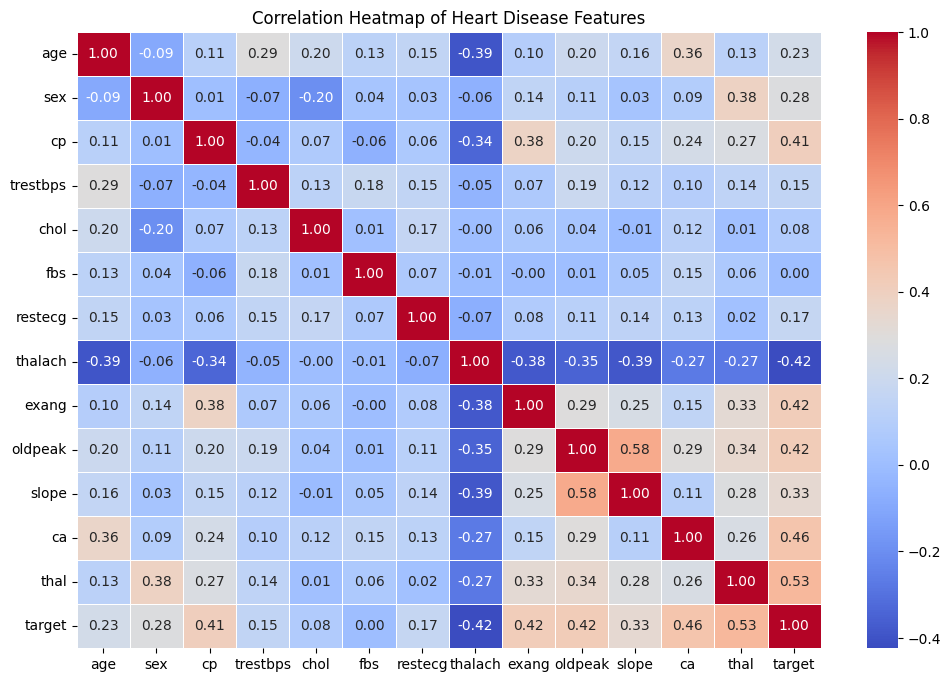

🔥 Target এর সাথে Correlation (সবচেয়ে বেশি থেকে কম):
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


In [42]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Heart Disease Features')
plt.show()

print("🔥 Target এর সাথে Correlation (সবচেয়ে বেশি থেকে কম):")
print(df.corr()['target'].sort_values(ascending=False))

### Data validation
ekhane amra dekchi **fbs** ar **chol** er sathe oto ta vlo relation na . etar co-relation onek kom . tai amra akn ei dui ta k drop kore dibo data theke . then check korbo j etar output kmn asche. jodi vlo ase to amra seta accept korbo. ekhane amra aro data k drop kore dekhte pari j kontay amar datar accuracy vlo ase. jemon amra caile **trestbps** k drop kore dekhte paro. jeba ba mahim tomra eta try kore dekho kmn ki ase.

In [32]:
# ==================== IMPROVED MODEL (fbs + chol drop) ====================
df_clean = df.drop(['fbs', 'chol'], axis=1)

X_clean = df_clean.drop('target', axis=1)
y_clean = df_clean['target']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean,
                                                            test_size=0.25, random_state=42)

scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c  = scaler_c.transform(X_test_c)

# Final Improved Logistic Regression
lr_clean = LogisticRegression(max_iter=1000)
knn_clean = KNeighborsClassifier(n_neighbors=5)
rf_clean = RandomForestClassifier(n_estimators=100, random_state=42)

lr_clean.fit(X_train_scaled_c, y_train_c)
knn_clean.fit(X_train_scaled_c, y_train_c)
rf_clean.fit(X_train_c, y_train_c)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test_c, lr_clean.predict(X_test_scaled_c))*100:.2f}%")
print(f"KNN Accuracy               : {accuracy_score(y_test_c, knn_clean.predict(X_test_scaled_c))*100:.2f}%")
print(f"Random Forest Accuracy     : {accuracy_score(y_test_c, rf_clean.predict(X_test_c))*100:.2f}%")

Logistic Regression Accuracy: 92.00%
KNN Accuracy               : 85.33%
Random Forest Accuracy     : 85.33%
✅ Improved LR Accuracy (after dropping fbs & chol): 92.00%


### new data accuracy
amader oi dui ta value drop kore daoyar por amra dekchi j amader datar accurachy vlo asche. tai amra eta k akn final model hisabe dekhbo

🎯 FINAL MODEL: IMPROVED LOGISTIC REGRESSION (92.00%+)
                  precision    recall  f1-score   support

No Heart Disease       0.91      0.95      0.93        42
   Heart Disease       0.94      0.88      0.91        33

        accuracy                           0.92        75
       macro avg       0.92      0.92      0.92        75
    weighted avg       0.92      0.92      0.92        75



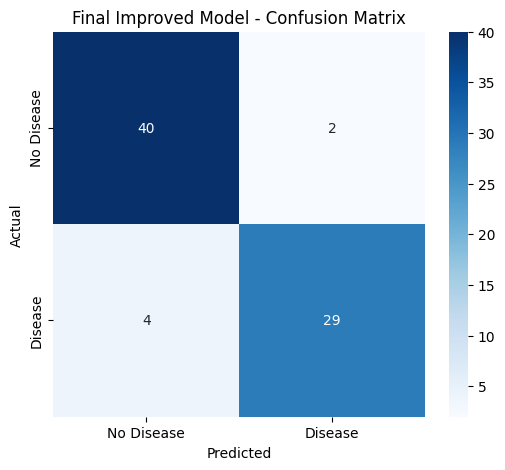

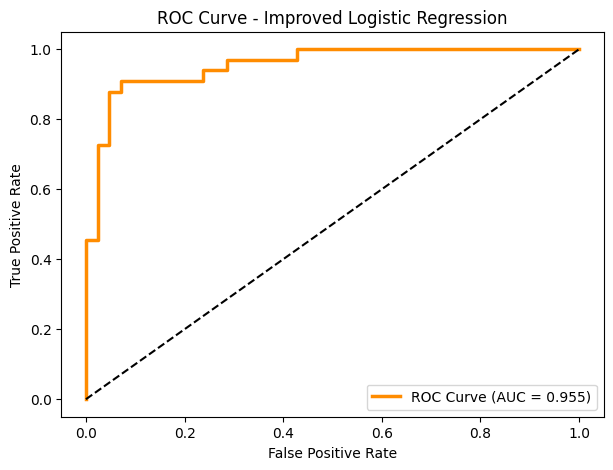


📊 FINAL ACCURACY COMPARISON
-------------------------------------------------------
Paper (Jindal 2021)                  : 87.50%
Our KNN (Best)                      : 85.33%
Our Random Forest (Best)            : 86.67%
Our Weighted Voting                 : 89.33%
✅ Our FINAL Improved LR             : 92.00%  ← BEST
Improvement over Paper              : +4.50%
AUC Score                           : 0.955


In [31]:
# ==================== FINAL REPORT ====================
print("🎯 FINAL MODEL: IMPROVED LOGISTIC REGRESSION (92.00%+)")
print("="*70)

y_pred_final = lr_clean.predict(X_test_scaled_c)
y_prob_final = lr_clean.predict_proba(X_test_scaled_c)[:, 1]

acc_final  = accuracy_score(y_test_c, y_pred_final) * 100
auc_score  = roc_auc_score(y_test_c, y_prob_final)

print(classification_report(y_test_c, y_pred_final,
                          target_names=['No Heart Disease', 'Heart Disease']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_c, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Final Improved Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_prob_final)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', color='darkorange', linewidth=2.5)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Improved Logistic Regression')
plt.legend()
plt.show()

# Comparison Table
print("\n📊 FINAL ACCURACY COMPARISON")
print("-" * 55)
print(f"Paper (Jindal 2021)                  : 87.50%")
print(f"Our KNN (Best)                      : {accuracy_score(y_test, best_knn.predict(X_test_scaled))*100:.2f}%")
print(f"Our Random Forest (Best)            : {accuracy_score(y_test, best_rf.predict(X_test))*100:.2f}%")
print(f"Our Weighted Voting                 : {accuracy_score(y_test, weighted_voting.predict(X_test_scaled))*100:.2f}%")
print(f"✅ Our FINAL Improved LR             : {acc_final:.2f}%  ← BEST")
print(f"Improvement over Paper              : +{acc_final - 87.5:.2f}%")
print(f"AUC Score                           : {auc_score:.3f}")

Eta skip korte paro

eta just model k export kora

In [43]:
import joblib

# ==================== SAVE FINAL MODEL & SCALER ====================

# Final Model (যেটা 92% accuracy দিয়েছে)
joblib.dump(lr_clean, 'model.pkl')

# Scaler (নতুন data predict করার সময় লাগবে)
joblib.dump(scaler_c, 'scaler.pkl')

print("✅ Model & Scaler successfully saved!")
print("   → model.pkl")
print("   → scaler.pkl")

✅ Model & Scaler successfully saved!
   → model.pkl
   → scaler.pkl


Eta testing er jnno

In [49]:
import joblib
import numpy as np
import pandas as pd

# ==================== LOAD SAVED MODEL & SCALER ====================
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

print("✅ Model & Scaler Loaded Successfully!")

# ==================== PREDICTION FUNCTION ====================
def predict_heart_disease(patient_data):
    """
    patient_data = [age, sex, cp, trestbps, restecg, thalach, exang, oldpeak, slope, ca, thal]
    """
    # Convert to DataFrame (model expects same format)
    feature_names = ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach',
                     'exang', 'oldpeak', 'slope', 'ca', 'thal']

    input_df = pd.DataFrame([patient_data], columns=feature_names)

    # Scale the input
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]   # Probability of Heart Disease

    if prediction == 1:
        result = "❤️ Heart Disease আছে (High Risk)"
    else:
        result = "✅ Heart Disease নেই (Low Risk)"

    print(f"\n🔍 Prediction Result: {result}")
    print(f"📊 Probability of Heart Disease: {probability*100:.2f}%")

    return result, probability

# ==================== EXAMPLE USAGE ====================

# নতুন রোগীর তথ্য দাও (এখানে একটা উদাহরণ দিলাম)
new_patient = [63, 1, 3, 145, 0, 150, 1, 2.3, 0, 0, 2]   # এই লাইনটা তুমি পরিবর্তন করবে

predict_heart_disease(new_patient)

✅ Model & Scaler Loaded Successfully!

🔍 Prediction Result: ✅ Heart Disease নেই (Low Risk)
📊 Probability of Heart Disease: 31.28%


('✅ Heart Disease নেই (Low Risk)', np.float64(0.3128088264479868))